# Summary

02_batch_inference.ipynb

Cohort-level workflow. Build a subjects CSV, run batch inference via the Python API (not the CLI), load `results_summary.csv` into pandas, and do some basic exploratory analysis — distribution plots of each output, a brain age gap scatter plot (predicted vs chronological age if a ground truth column is available). 

# Install

Unfortunately due to dependency conflicts between Tensorflow 2.13 and ipython, installation needs to take place outside the notebook in your ipykernel environment (unless you're running a kernel from the NeuroFM docker container, then you can skip this step).

Please run the following in your terminal Python environment before starting the kernel (mamba, etc.) to create and activate a dedicated environment, then install dependencies:
```bash
pip install "neurofm[notebooks] @ git+https://github.com/rockNroll87q/NeuroFM.git"
pip install templateflow==24.1.0 "numpy<=1.24.3" "typing-extensions<4.6.0"
```

**Note:** The `typing-extensions` pin is required for TensorFlow compatibility. Installing inside the notebook is not recommended as it conflicts with ipython's own dependencies. 


If you run into issues, we recommend using the NeuroFM notebook docker container `rocknroll87q/neurofm:notebook`:

Run: `docker run --rm -p 8888:8888 rocknroll87q/neurofm:notebook`.

Open your browser to `http://localhost:8888`.

# Inference tests

In [17]:
# First import takes ~ 30-40s due to internal TensorFlow imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from neurofm import NeuroFM
from neurofm.io import infer_input_root, load_and_preprocess, resolve_inputs, save_batch_summary
from neurofm.model import BRAIN_HEALTH_KEYS

### Config options

In [18]:
NEUROFM_VARIANT = 'neurofm-m'
DEVICE = 'cpu'
OUT_ROOT = Path('/tmp/neurofm_results')

## Generate template test vols

In this example, we generate skull-stripped test volumes as our input MRI data. You can replace this test data with your preferred dataset of choice.

In [19]:
!python ../scripts/get_test_data.py --output /tmp/test_data/ --mode template -n 20


NeuroFM test data utility
  Mode   : template
  Output : /tmp/test_data/
  N      : 20

Fetching MNI152NLin2009cAsym 1mm T1w template from TemplateFlow...
Template downloaded: /Users/austind/Library/Caches/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-01_desc-brain_T1w.nii.gz
  Written: /tmp/test_data/MNI152_test_01.nii.gz
  Written: /tmp/test_data/MNI152_test_02.nii.gz
  Written: /tmp/test_data/MNI152_test_03.nii.gz
  Written: /tmp/test_data/MNI152_test_04.nii.gz
  Written: /tmp/test_data/MNI152_test_05.nii.gz
  Written: /tmp/test_data/MNI152_test_06.nii.gz
  Written: /tmp/test_data/MNI152_test_07.nii.gz
  Written: /tmp/test_data/MNI152_test_08.nii.gz
  Written: /tmp/test_data/MNI152_test_09.nii.gz
  Written: /tmp/test_data/MNI152_test_10.nii.gz
  Written: /tmp/test_data/MNI152_test_11.nii.gz
  Written: /tmp/test_data/MNI152_test_12.nii.gz
  Written: /tmp/test_data/MNI152_test_13.nii.gz
  Written: /tmp/test_data/MNI152_test_14.nii.gz
  Written: /tmp/test_data/MNI15

## Get input paths

In `neurofm`, `resolve_inputs` is a utility to get the input paths from a single image, directory, or a .csv. The function assumes the input column containing your path strings is "input", but this can be changed with `resolve_inputs(..., input_col="path_col")`.

In [20]:
dataset_root = Path('/tmp/test_data/subjects.csv')
input_paths = resolve_inputs(dataset_root)
input_root = infer_input_root(input_paths)
input_root = Path(input_root)

2026-03-26 16:33:16.227 | INFO     | neurofm.io:resolve_inputs:76 - Resolved 20 input file(s).


In [21]:
input_paths

[PosixPath('/tmp/test_data/MNI152_test_01.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_02.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_03.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_04.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_05.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_06.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_07.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_08.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_09.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_10.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_11.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_12.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_13.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_14.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_15.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_16.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_17.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_18.nii.gz'),
 PosixPath('/tmp/test_data/MNI152_test_19.nii.gz'),
 PosixPath('

## Run NeuroFM Inference

In [22]:
# We add some noise perturbations to every template volume so that the predictions vary somewhat
def add_noise(vol:np.ndarray):
    noise = np.random.normal(0.0, 0.1, size=vol.shape)
    return vol + noise

In [ ]:
model = NeuroFM(
    variant=NEUROFM_VARIANT,
    device=DEVICE,
    custom_postproc_fn = add_noise
)

In [24]:
# On modern CPU, takes a few seconds per volume (currently not running in parallel batches)
batch_results = model.predict_batch(input_paths, outputs=['brain_health','latent'])

2026-03-26 16:33:26.933 | INFO     | neurofm.inference:predict_batch:161 - [1/20] Processing: /tmp/test_data/MNI152_test_01.nii.gz
2026-03-26 16:33:26.938 | DEBUG    | neurofm.io:_reorient:163 - Reorienting from 'RAS' to 'LIA'.
2026-03-26 16:33:26.982 | DEBUG    | neurofm.io:_resample:186 - Resampling: shape (193, 193, 229) -> (256, 256, 256), zooms (1.0, 1.0, 1.0) -> (1.0, 1.0, 1.0).
2026-03-26 16:33:31.888 | INFO     | neurofm.inference:predict_batch:161 - [2/20] Processing: /tmp/test_data/MNI152_test_02.nii.gz
2026-03-26 16:33:31.889 | DEBUG    | neurofm.io:_reorient:163 - Reorienting from 'RAS' to 'LIA'.
2026-03-26 16:33:31.915 | DEBUG    | neurofm.io:_resample:186 - Resampling: shape (193, 193, 229) -> (256, 256, 256), zooms (1.0, 1.0, 1.0) -> (1.0, 1.0, 1.0).
2026-03-26 16:33:37.425 | INFO     | neurofm.inference:predict_batch:161 - [3/20] Processing: /tmp/test_data/MNI152_test_03.nii.gz
2026-03-26 16:33:37.429 | DEBUG    | neurofm.io:_reorient:163 - Reorienting from 'RAS' to 'LI

In [25]:
len(batch_results)

20

## Toy plot example

2026-03-26 16:36:48.163 | DEBUG    | neurofm.io:_reorient:163 - Reorienting from 'RAS' to 'LIA'.


2026-03-26 16:36:48.219 | DEBUG    | neurofm.io:_resample:186 - Resampling: shape (193, 193, 229) -> (256, 256, 256), zooms (1.0, 1.0, 1.0) -> (1.0, 1.0, 1.0).


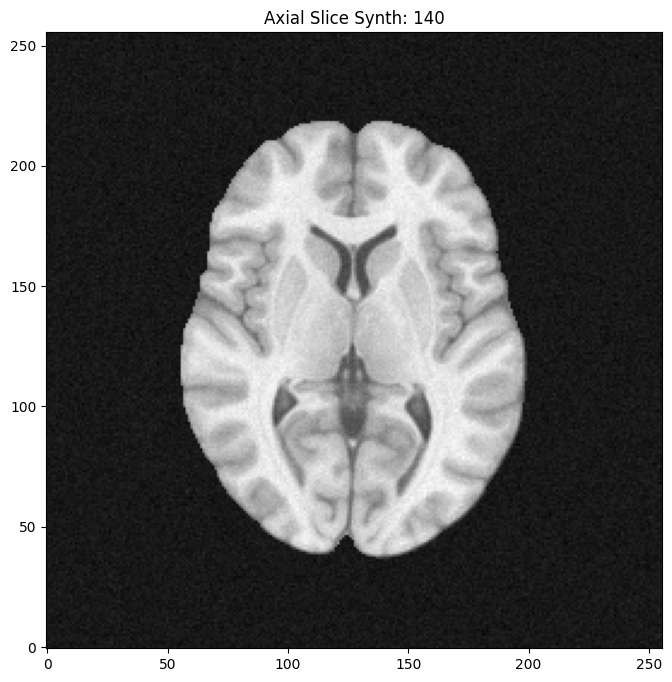

In [26]:
# Example of our template volume inputs from above
volume = load_and_preprocess(input_paths[0])
volume = add_noise(volume)

slice_num = 140
slice_synth = volume[0, :, slice_num, :, 0]

plt.figure(figsize=(8,8))
plt.imshow(slice_synth.T, cmap='gray', origin='lower')
plt.title(f'Axial Slice Synth: {slice_num}')
plt.show()

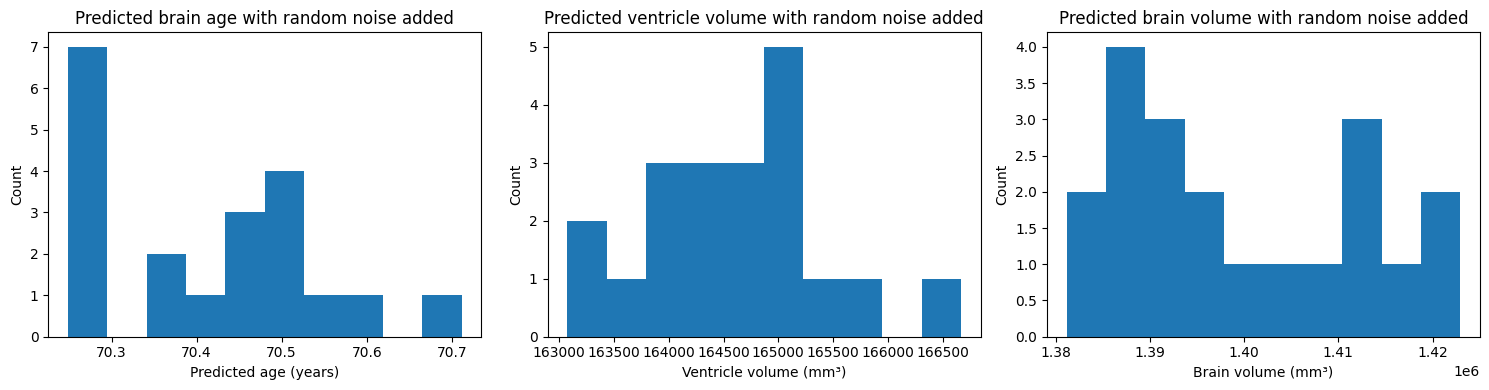

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

regression_keys = ["brain_age", "ventricle_volume", "brain_volume"]
xlabels = ["Predicted age (years)", "Ventricle volume (mm³)", "Brain volume (mm³)"]

for ax, key, xlabel in zip(axes, regression_keys, xlabels):
    idx = BRAIN_HEALTH_KEYS.index(key)
    ax.hist(x=np.array([res['brain_health'][idx] for res in batch_results]))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(f'Predicted {key.replace("_", " ")} with random noise added')

plt.tight_layout()
plt.show()

Results can be manipulated in memory, or saved to disk for later analysis.

## Save outputs

In [28]:
# scripts/run_inference.py has a caching mechanism, but we won't copy that here for brevity

## Optional: save individual output files
# for path, result in zip(input_paths, batch_results):
#     if result is None:
#         continue
#     try:
#         save_outputs(
#             result, 
#             path, 
#             OUT_ROOT, 
#             requested_outputs=['brain_health','latent'], 
#             output_mode='flat', 
#         )
#     except Exception as e:
#         print(f"Failed to save outputs for {path}: {e}")

# Write aggregate files to OUT_ROOT
save_batch_summary(
    batch_results, 
    input_paths, 
    OUT_ROOT, 
    ['brain_health','latent'],
)

2026-03-26 16:37:05.533 | INFO     | neurofm.io:save_batch_summary:428 - Summary CSV written -> /tmp/neurofm_results/results_summary.csv (20 scan(s))
2026-03-26 16:37:05.537 | INFO     | neurofm.io:save_batch_summary:439 - Latent embeddings written -> /tmp/neurofm_results/latent_embeddings.npy (shape: (20, 256)), index -> /tmp/neurofm_results/latent_embeddings_index.csv


In [29]:
!ls /tmp/neurofm_results/

latent_embeddings.npy       results_summary.csv
latent_embeddings_index.csv


In [30]:
import pandas as pd

pd.read_csv('/tmp/neurofm_results/results_summary.csv')

,input,brain_age,sex,ventricle_volume,brain_volume
0,/tmp/test_data/MNI152_test_01.nii.gz,70.252197,0.0,164365.218750,1416567.125
1,/tmp/test_data/MNI152_test_02.nii.gz,70.711433,0.0,166667.984375,1381132.000
2,/tmp/test_data/MNI152_test_03.nii.gz,70.514313,0.0,165210.328125,1383301.250
3,/tmp/test_data/MNI152_test_04.nii.gz,70.269806,0.0,163851.265625,1410766.250
4,/tmp/test_data/MNI152_test_05.nii.gz,70.437668,0.0,165031.703125,1386120.750
5,/tmp/test_data/MNI152_test_06.nii.gz,70.248650,0.0,165290.390625,1393896.500
6,/tmp/test_data/MNI152_test_07.nii.gz,70.262947,0.0,163836.421875,1411317.000
7,/tmp/test_data/MNI152_test_08.nii.gz,70.463753,0.0,164595.500000,1405020.125
8,/tmp/test_data/MNI152_test_09.nii.gz,70.252090,0.0,163776.421875,1413169.875
9,/tmp/test_data/MNI152_test_10.nii.gz,70.475708,0.0,164439.781250,1398681.625
